In [24]:
import pandas as pd
import numpy as np 
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
df=pd.read_csv("C:\\Users\\DELL\\Downloads\\telco_preprocessed_full.xls")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,0.0,1,29.85,29.85,0,0.0,0.0,0.0,1.0,0.0
1,1,0,0,0,34,1,0,1,0,1,...,1.0,0,56.95,1889.50,0,0.0,0.0,0.0,0.0,1.0
2,1,0,0,0,2,1,0,1,1,0,...,0.0,1,53.85,108.15,1,0.0,0.0,0.0,0.0,1.0
3,1,0,0,0,45,0,0,1,0,1,...,1.0,0,42.30,1840.75,0,0.0,0.0,0.0,0.0,0.0
4,0,0,0,0,2,1,0,0,0,0,...,0.0,1,70.70,151.65,1,1.0,0.0,0.0,1.0,0.0


In [25]:
x = df.drop("Churn", axis=1)
y = df["Churn"]
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
#model training 
svm_model = SVC(kernel="rbf", probability=True)
svm_model.fit(x_train, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [26]:
#model evaluation 
y_pred = svm_model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8126330731014905
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.70      0.51      0.59       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [29]:
y_proba = svm_model.predict_proba(x_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.820832082561305


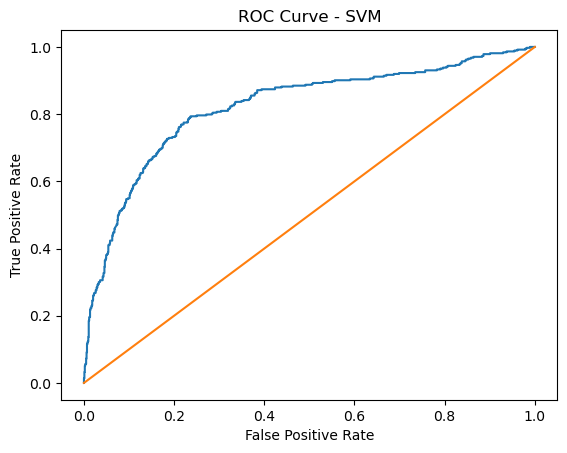

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.show()

In [31]:
#model tuning (recall for churn (class 1) was low,so we use class balancing to improve detection of churners)
svm_model_balanced = SVC(
    kernel='rbf',#curved boundary(non linear)
    C=1,#C controls how strict the model is
    gamma='scale', #How far the influence of each training point reaches
    class_weight='balanced',#to balance between churners and no churners 
    probability=True #for predincting probabilities not just binary values
)
svm_model_balanced.fit(x_train, y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [33]:
#model evaluation 
y_pred = svm_model_balanced.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
#the recall jumped from 0.51 to 0.81 

Accuracy: 0.7579843860894251
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1036
           1       0.53      0.80      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



ROC-AUC: 0.8421322989017357


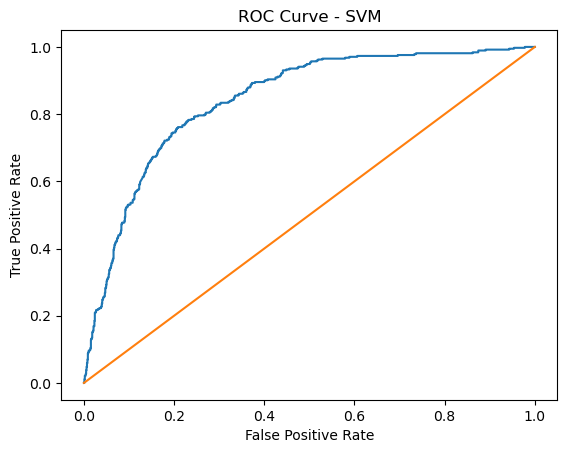

In [35]:
y_proba = svm_model_balanced.predict_proba(x_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", roc_auc)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.show()